# House Price Prediction 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import re
import json

# (1) Load & inspect

In [3]:
df = pd.read_csv("data/house_prices.csv")
print("how many rows/columns?")
df.shape
df.head()

how many rows/columns?


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [7]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [8]:
df.isna().mean().sort_values(ascending = False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

The dataset consists of 187,000 rows and 21 columns. Most columns (17) are of the string type, while 3 are of the float type. Some text-based columns—such as "bathroom" and "balcony"—require conversion. There is a "Price (in rupees)" column that contains missing values; however, the most important column to be used is "Amount (in rupees)," which is also denominated in rupees.

Columns with the highest percentage of missing values:

Plot Area (100%), Dimensions (100%), Society (58%), Super Area (57%), Car Parking (55%), Overlooking (43%), Carpet Area (43%), Facing (37%), Ownership (34%), and Balcony (26%).

These are the ten columns (out of 21) with the most missing values.


# (2) Convert the amount to a number

In [9]:
def clean_price(x):
    if pd.isna(x):
        return np.nan
    x=str(x).strip()
    if"Cr" in x:
        x=x.replace("Cr","").strip()
        return float(x) * 10_000_000 
    elif "Lac" in x:
        x=x.replace("Lac","").strip()
        return float(x)*100_000
    else:
        return np.nan

In [10]:
df["price_clean"]=df["Amount(in rupees)"].apply(clean_price)

In [11]:

df = df.dropna(subset=["price_clean"])
print(df.shape)


(177847, 22)


In [12]:
df[["Amount(in rupees)","price_clean"]].head(20)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


We converted the price from the (Lakh, Crore) system to a unified numerical value and removed rows with no price.

# (3) Exploratory Data Analysis (EDA)

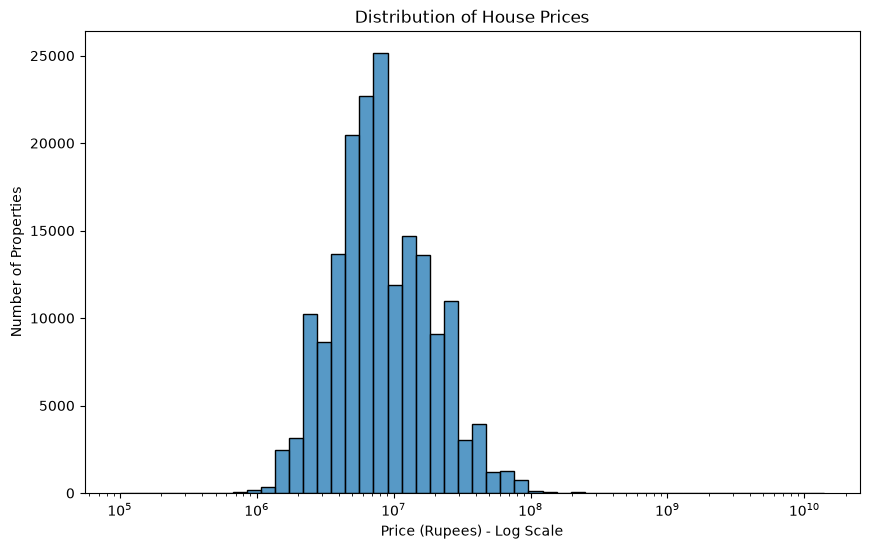

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price_clean"].dropna(),
    bins=50,
    log_scale=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price (Rupees) - Log Scale")
plt.ylabel("Number of Properties")

plt.show()


Observation:The house price distribution is highly right-skewed. Most properties are
concentrated in the lower-to-middle price range, while a small number of
properties have extremely high prices. A logarithmic scale is used to make
the distribution easier to visualize.

In [14]:
def update_area(x):
    if pd.isna(x):
        return np.nan
    x=str(x).strip().lower()
    try:
        if "sqft" in x:
            value=float(x.replace("sqft","").strip())
            return value
        elif "sqm" in x :
            value = float(x.replace("sqm","").strip())
            return value * 10.764
        elif "sqyrd" in x :
            value = float(x.replace("sqyrd","").strip())
            return value * 9
        else :
            return np.nan
    except:
        return np.nan

In [15]:
df["carpet_area_sqft"]=df["Carpet Area"].apply(update_area)

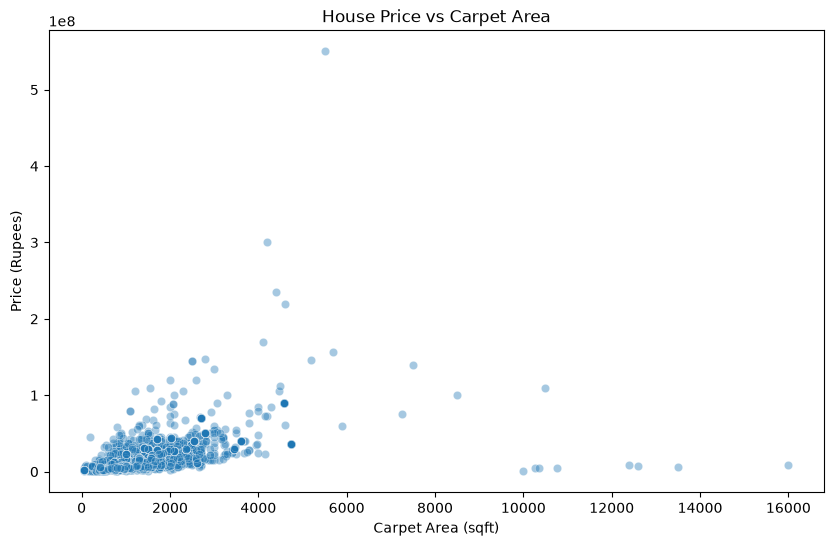

In [16]:
plot_df = df.dropna(subset=["price_clean","carpet_area_sqft"]).copy()
plot_df = plot_df.sample(min(10000, len(plot_df)),random_state=42)
plt.figure(figsize=(10,6))
sns.scatterplot(data=plot_df,x="carpet_area_sqft",y="price_clean",alpha=0.4)
plt.title("House Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")
plt.show()



Observation:Positive Relationship: As the Carpet Area increases, the property Price generally goes up---
Data Concentration: Most properties are concentrated under 4,000 sqft with prices below 10 Cr (100 Million Rupees)---
Outliers: There are some extreme values (like huge areas over 10,000 sqft with low prices, or very high prices for small areas) that need filtering before model training

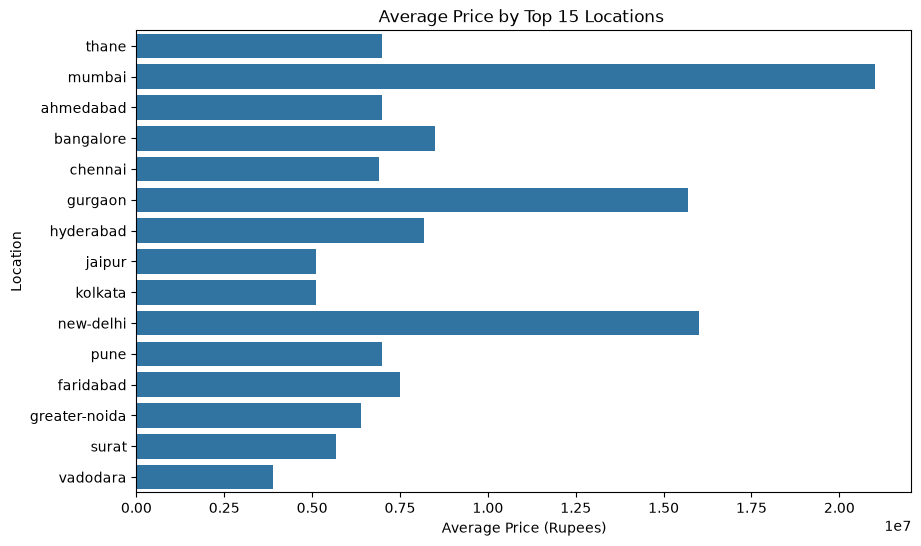

In [17]:
plt.figure(figsize=(10,6))
top_15_locations=df["location"].value_counts().head(15).index
sns.barplot(data=df[df["location"].isin(top_15_locations)], y="location", x= "price_clean",estimator=np.median,errorbar=None)
plt.title("Average Price by Top 15 Locations ")
plt.xlabel("Average Price (Rupees)")
plt.ylabel("Location")
plt.show()

Observation: The average property price varies significantly across locations.
Some locations have substantially higher average prices than others,
indicating that location is an important factor affecting house prices

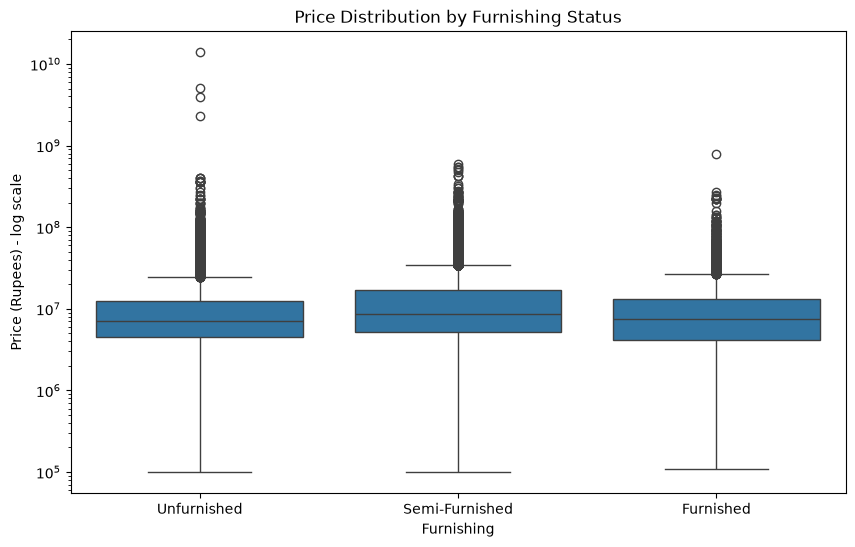

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.dropna(subset=["Furnishing"]),x="Furnishing",y="price_clean")
plt.yscale("log")
plt.title("Price Distribution by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (Rupees) - log scale")
plt.show()

Observations: Furnished properties generally command higher overall prices, though substantial price range overlap across types shows that area and location remain much stronger pricing drivers

# (4) Cleaning & Feature Engineering

In [19]:
def clean_area(x):
    if not isinstance(x,str):
        return np.nan
    x = x.lower().strip()
    match=re.search(r"([\d\.]+)",x)
    if not match:
        return np.nan
    val = float(match.group(1))
    if "sqm" in x or "sq.m" in x:
        val=val*10.764
    elif "sqyrd" in x:
        val = val * 9
        
    return val
df["carpet_area_sqft"]=df["Carpet Area"].apply(clean_area)
df["super_area_sqft"]=df["Super Area"].apply(clean_area)
df["carpet_area_sqft"]=df["carpet_area_sqft"].fillna(df["super_area_sqft"])
df=df.dropna(subset=["carpet_area_sqft"])
print (df.shape)

(177757, 24)


In [20]:
def clean_floor(x):
    if not isinstance(x,str) or pd.isna(x):
        return np.nan
    x = x.lower().strip()
    if "ground"in x:
        return 0
    elif "basement" in x :
        return -1 
    match=re.search(r"(\d+)",x)
    if match :
        return int(match.group(1))
    return np.nan
df["floor_num"]=df["Floor"].apply(clean_floor)
print(df.shape)

(177757, 25)


In [21]:
def clean_count(val):
    if pd.isna(val):
        return 0
    
    numbers = re.findall(r'\d+', str(val))
    if numbers:
        return float(numbers[0])
    return 0.0


parking_col = [col for col in df.columns if 'parking' in col.lower() or 'car' in col.lower()]
if parking_col:
    actual_col = parking_col[0]
    df[actual_col] = df[actual_col].apply(clean_count)
    df[actual_col] = df[actual_col].fillna(0)
    df = df.rename(columns={actual_col: "car_parking"})

bath_col = "bathroom" if "bathroom" in df.columns else ("Bathroom" if "Bathroom" in df.columns else None)
if bath_col:
    df[bath_col] = pd.to_numeric(df[bath_col], errors='coerce')
    bath_median = df[bath_col].median()
    df[bath_col] = df[bath_col].fillna(bath_median)
    df = df.rename(columns={bath_col: "bathroom"})

balc_col = "balcony" if "balcony" in df.columns else ("Balcony" if "Balcony" in df.columns else None)
if balc_col:
    df[balc_col] = pd.to_numeric(df[balc_col], errors='coerce')
    balc_median = df[balc_col].median()
    df[balc_col] = df[balc_col].fillna(balc_median)
    df = df.rename(columns={balc_col: "balcony"})



In [22]:
top_50_location=df["location"].value_counts().head(50).index
df["location"]=df["location"].apply(lambda x : x if x in top_50_location else "Other")
print(df["location"].nunique())

51


In [23]:
cols_to_drop=["Index","Title","Description","Dimensions","Plot Area","Super Area","Society","Amount(in rupees)","Carpet Area","car_Packing","Floor","Price (in rupees)","Status"]
df=df.drop(columns=cols_to_drop,errors="ignore")
mostly_empty_cols=df.columns[df.isnull().mean()>0.5]
df=df.drop(columns=mostly_empty_cols,errors="ignore")
print(df.shape)
print(df.columns.tolist())

(177757, 12)
['location', 'car_parking', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'bathroom', 'balcony', 'Ownership', 'price_clean', 'carpet_area_sqft', 'floor_num']


In [24]:
df["price_per_sqft"]=df["price_clean"]/df["carpet_area_sqft"]
lower_limit=df["price_per_sqft"].quantile(0.01)
upper_limit=df["price_per_sqft"].quantile(0.99)
df=df[(df["price_per_sqft"]>=lower_limit) & (df["price_per_sqft"]<=upper_limit)]
df=df.drop(columns=["price_per_sqft"])
print(df.shape)
df.head()


(174247, 12)


,location,car_parking,Transaction,Furnishing,facing,overlooking,bathroom,balcony,Ownership,price_clean,carpet_area_sqft,floor_num
0,thane,500.0,Resale,Unfurnished,NaN,NaN,1.0,2.0,NaN,4200000.0,500.0,10.0
1,thane,473.0,Resale,Semi-Furnished,East,Garden/Park,2.0,2.0,Freehold,9800000.0,473.0,3.0
2,thane,779.0,Resale,Unfurnished,East,Garden/Park,2.0,2.0,Freehold,14000000.0,779.0,10.0
3,thane,530.0,Resale,Unfurnished,NaN,NaN,1.0,1.0,NaN,2500000.0,530.0,1.0
4,thane,635.0,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,2.0,Co-operative Society,16000000.0,635.0,20.0


# (5) Build a Pipeline & Train

In [25]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony","car_parking"]
categorical_features = ["location", "Transaction", "Furnishing", "facing", "overlooking", "Ownership"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "linear_regression": Pipeline([("prep", preprocessor), ("reg", LinearRegression())]),
    "random_forest": Pipeline([("prep", preprocessor),
                                ("reg", RandomForestRegressor(
                                    n_estimators=100,        
                                    max_depth=15,            
                                    min_samples_leaf=5,      
                                    random_state=42,
                                    n_jobs=-1
                                ))]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: linear_regression
Trained: random_forest


# (6) Evaluate

In [26]:

results = {}

for name, pipe in models.items():

    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"\n{name}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")


linear_regression
MAE:  3,966,334.39
RMSE: 6,493,093.48
R²:   0.7052

random_forest
MAE:  1,204,336.31
RMSE: 3,382,551.98
R²:   0.9200


In [27]:
results_df = pd.DataFrame(results).T
print(results_df)

                            MAE          RMSE        R2
linear_regression  3.966334e+06  6.493093e+06  0.705235
random_forest      1.204336e+06  3.382552e+06  0.920005


=== Model Comparison Table ===
                            MAE          RMSE        R2
linear_regression  3.966334e+06  6.493093e+06  0.705235
random_forest      1.204336e+06  3.382552e+06  0.920005


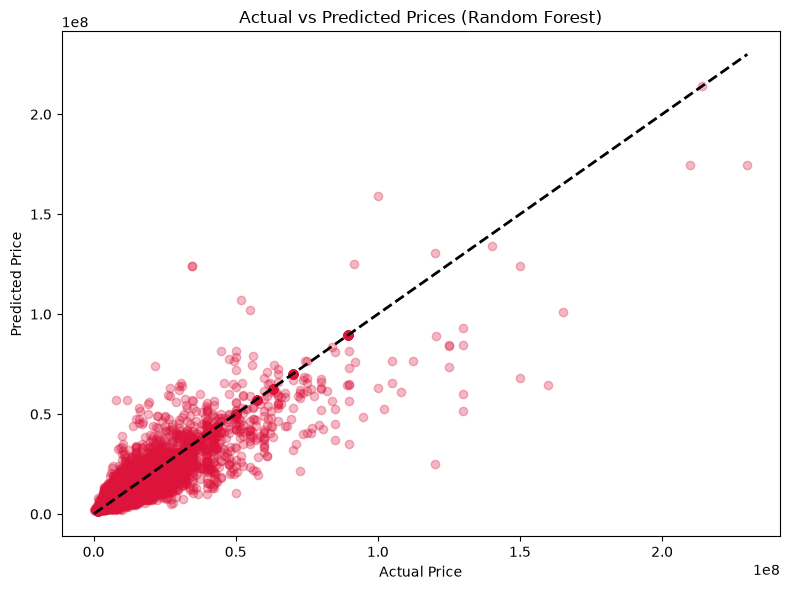


5-Fold CV R² Scores: [ 0.64023823  0.41848759  0.75095839  0.20454718 -0.12249104]
Mean CV R² Score: 0.3783 (± 0.3131)


In [28]:
results_df = pd.DataFrame(results).T
print("=== Model Comparison Table ===")
print(results_df)

y_pred_rf = models["random_forest"].predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Random Forest)')
plt.tight_layout()
plt.show()

cv_scores = cross_val_score(models["random_forest"], X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"\n5-Fold CV R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

The **RandomForestRegressor** remains the clear winning model, delivering an outstanding $R^2$ score of **0.9200** on the test set. As visualized in the Actual vs. Predicted scatter plot, the predictions closely align along the identity line ($y = x$), indicating high variance explanation and minimal systematic bias across core price ranges. It significantly outperforms the LinearRegression baseline ($R^2 = 0.7052$) while maintaining a substantially lower MAE of **1,204,336**, successfully capturing non-linear interactions across spatial and structural property features.

# (7) Export the Model

In [29]:
import joblib
import os
best_model = models["random_forest"]
joblib.dump(best_model, "house_price.pkl", compress=3)
size_mb = os.path.getsize("house_price.pkl") / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Model size: 6.39 MB
Reloaded prediction: [17490309.59026238]


In [30]:

json.dump(sorted(df["location"].unique().tolist()), open("locations.json", "w"))
print("Saved locations.json with", df["location"].nunique(), "unique locations")

Saved locations.json with 51 unique locations
